# Exercise 1 — Separable Data

Runnable code for the *Perceptron* deliverable. Two well-separated 2-D Gaussian
clouds are classified with a single-layer perceptron written from scratch (see
`perceptron.py`). All randomness comes from a single fixed generator
(`rng = np.random.default_rng(42)`); the perceptron is re-created from the same
seed for each learning-rate run so the two runs differ *only* in $\eta$.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from perceptron import Perceptron

%matplotlib inline

FIG_DIR = Path("..") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
COLORS = {0: "#1f77b4", 1: "#d62728"}


def build_data(rng):
    """Two separable Gaussian clouds, 1000 samples per class."""
    X0 = rng.multivariate_normal([1.5, 1.5], [[0.5, 0.0], [0.0, 0.5]], size=1000)
    X1 = rng.multivariate_normal([5.0, 5.0], [[0.5, 0.0], [0.0, 0.5]], size=1000)
    X = np.vstack([X0, X1])
    y = np.concatenate([np.zeros(1000, dtype=int), np.ones(1000, dtype=int)])
    return X, y


def run(eta):
    """Fresh seed -> identical data and init; only eta changes."""
    rng = np.random.default_rng(42)
    X, y = build_data(rng)
    model = Perceptron(n_features=2, rng=rng, lr=eta)
    history, best = model.train(X, y, max_epochs=100, pocket=False)
    return X, y, model, history

## A — Generate the data

Class 0 $\sim \mathcal{N}([1.5,1.5], 0.5 I)$ and Class 1 $\sim \mathcal{N}([5,5], 0.5 I)$, 1000 points each. The means are ~5 units apart while
the standard deviation is only ~0.7, so the clouds are cleanly separable.


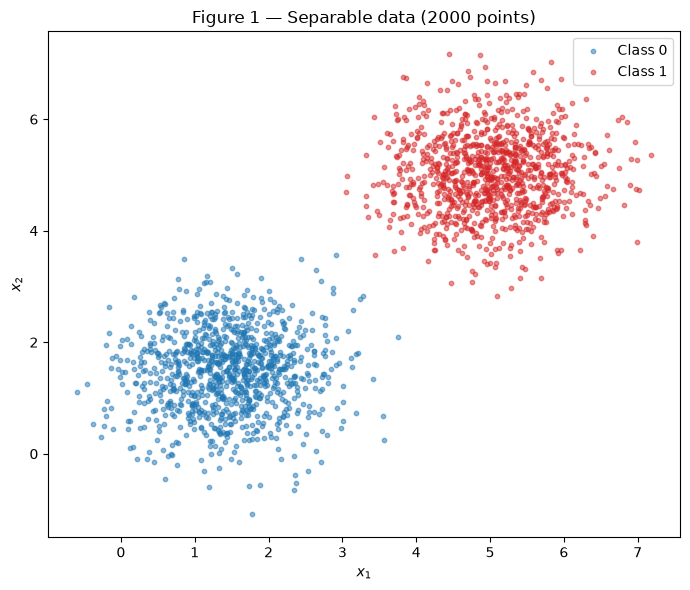

In [2]:
rng = np.random.default_rng(42)
X, y = build_data(rng)

fig, ax = plt.subplots(figsize=(7, 6))
for k in (0, 1):
    ax.scatter(X[y == k, 0], X[y == k, 1], s=10, alpha=0.5,
               color=COLORS[k], label=f"Class {k}")
ax.set_title("Figure 1 — Separable data (2000 points)")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_separable_data.png", dpi=150)
plt.show()

## B — The perceptron

The model is implemented from scratch in `perceptron.py` and imported above:
`step`, `predict`, the $\{0,1\}$ error-driven update
$w \leftarrow w + \eta (y - \hat{y}) x$, non-zero initialization
(`rng.normal(0, 0.01, size=2)`, $b = 0$), $\eta = 0.01$, and stopping when a full
pass produces no update (max 100 epochs).

In [3]:
import inspect
import perceptron
print(inspect.getsource(perceptron.Perceptron.train))

    def train(self, X, y, max_epochs=100, pocket=False):
        """Train until a full pass produces no update, or max_epochs.

        Returns a history dict (per-epoch accuracy, best-so-far accuracy, and
        update count) and the pocket record (best weights, bias, accuracy, and
        the epoch at which the best occurred).
        """
        n = len(y)
        best = {
            "w": self.w.copy(),
            "b": self.b,
            "acc": self.accuracy(X, y),
            "epoch": 0,
        }
        history = {"acc": [], "best_acc": [], "updates": []}

        for epoch in range(1, max_epochs + 1):
            updates = 0
            for i in range(n):
                xi, yi = X[i], y[i]
                y_hat = 1 if (self.w @ xi + self.b) >= 0 else 0
                error = yi - y_hat            # 0 if correct, +/-1 on a mistake
                if error != 0:
                    self.w = self.w + self.lr * error * xi
                    self.b = self.b + self.lr * error
 

## C — Train and measure

In [4]:
X, y, model, history = run(0.01)
epochs = len(history["acc"])
final_acc = history["acc"][-1]
print(f"Final w = {model.w}")
print(f"Final b = {model.b:.4f}")
print(f"Epochs to convergence = {epochs}")
print(f"Final accuracy = {final_acc:.4f}")

Final w = [0.05049707 0.02887168]
Final b = -0.2500
Epochs to convergence = 26
Final accuracy = 1.0000


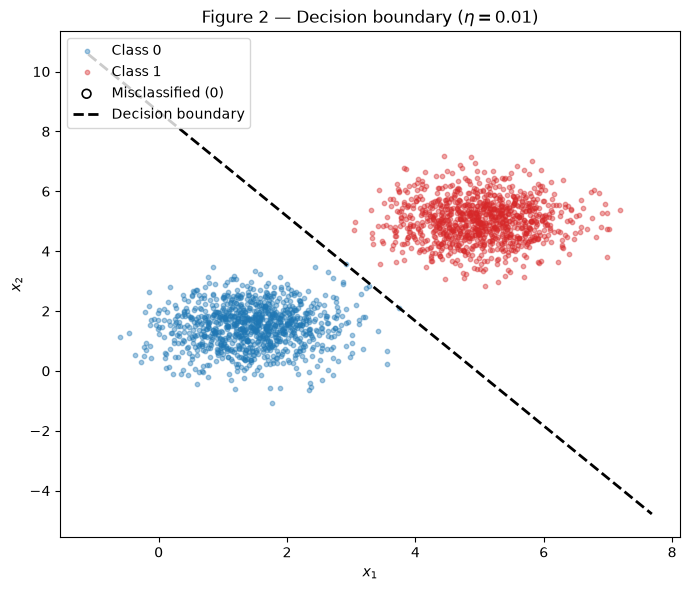

In [5]:
def plot_boundary(ax, model, X, y, title):
    for k in (0, 1):
        ax.scatter(X[y == k, 0], X[y == k, 1], s=10, alpha=0.4,
                   color=COLORS[k], label=f"Class {k}")
    mis = model.predict(X) != y
    ax.scatter(X[mis, 0], X[mis, 1], s=40, facecolors="none",
               edgecolors="black", linewidths=1.2,
               label=f"Misclassified ({mis.sum()})")
    x1 = np.array([X[:, 0].min() - 0.5, X[:, 0].max() + 0.5])
    if abs(model.w[1]) > 1e-12:
        x2 = -(model.w[0] * x1 + model.b) / model.w[1]
        ax.plot(x1, x2, "k--", lw=2, label="Decision boundary")
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.legend(loc="upper left")


fig, ax = plt.subplots(figsize=(7, 6))
plot_boundary(ax, model, X, y, "Figure 2 — Decision boundary ($\\eta = 0.01$)")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_boundary.png", dpi=150)
plt.show()

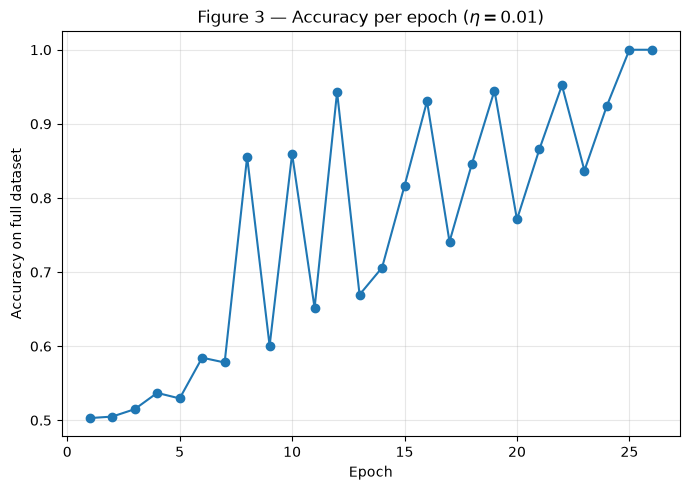

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(range(1, epochs + 1), history["acc"], marker="o")
ax.set_title("Figure 3 — Accuracy per epoch ($\\eta = 0.01$)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy on full dataset")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_accuracy.png", dpi=150)
plt.show()

## D — Analysis

### D.2 — learning-rate comparison ($\eta = 0.01$ vs $\eta = 1.0$)

Same data, same initialization, only $\eta$ changes.

In [7]:
results = {}
for eta in (0.01, 1.0):
    _, _, m, h = run(eta)
    direction = m.w / np.linalg.norm(m.w)
    results[eta] = (m, h, direction)
    print(f"eta = {eta}:  epochs = {len(h['acc'])},  final acc = {h['acc'][-1]:.4f}")
    print(f"           w = {m.w},  b = {m.b:.4f}")
    print(f"           w/||w|| = {direction}")

d_small = results[0.01][2]
d_big = results[1.0][2]
cos = float(np.clip(d_small @ d_big, -1, 1))
print(f"\ncosine similarity between the two weight directions = {cos:.4f}")
print(f"angle between them = {np.degrees(np.arccos(cos)):.2f} degrees")

eta = 0.01:  epochs = 26,  final acc = 1.0000
           w = [0.05049707 0.02887168],  b = -0.2500
           w/||w|| = [0.86812305 0.49634905]
eta = 1.0:  epochs = 37,  final acc = 1.0000
           w = [5.87061596 3.3592393 ],  b = -31.0000
           w/||w|| = [0.86794992 0.49665172]

cosine similarity between the two weight directions = 1.0000
angle between them = 0.02 degrees
